In [ ]:
import numpy as np
import os
from OrthoSAM.synthetic.synthetic_assessment import prediction_based_accuracy
import matplotlib.pyplot as plt
head='/DATA/vito/output/'
def get_synth_ac(Ds, head):
    return [os.path.join(head+Ds, f) for f in os.listdir(head+Ds)]
s05 = get_synth_ac('ran_synth_12_1500_shadow2_0_5', head)
s05.sort()

In [ ]:
aps=[0.929, 0.873, 0.777, 0.863, 0.948, 0.919, 0.866, 0.895, 0.786, 0.864]
aps

[0.929, 0.873, 0.777, 0.863, 0.948, 0.919, 0.866]

/DATA/vito/data/ran_synth_12_1500_shadow2_0_5/img/img_09_60_180.npy imported
Mask imported from /DATA/vito/output/ran_synth_12_1500_shadow2_0_5/ran_synth_12_1500_shadow2_0_5_09_b250/Merged/Merged_Layers_001.npy
masks size: (10000, 10000)
2217  mask(s) loaded
No. of actual objects: 2294
AP@0.75: 0.895


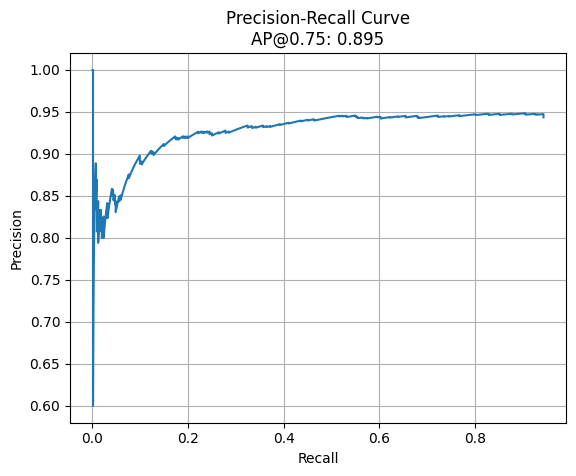

/DATA/vito/data/ran_synth_12_1500_shadow2_0_5/img/img_10_70_180.npy imported
Mask imported from /DATA/vito/output/ran_synth_12_1500_shadow2_0_5/ran_synth_12_1500_shadow2_0_5_10_b250/Merged/Merged_Layers_001.npy
masks size: (10000, 10000)
2221  mask(s) loaded
No. of actual objects: 2294
AP@0.75: 0.786


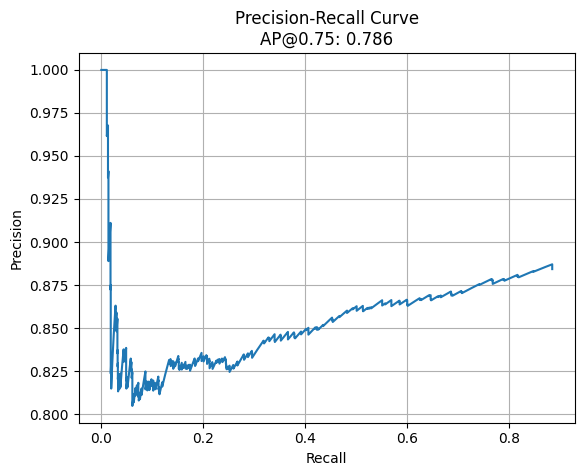

/DATA/vito/data/ran_synth_12_1500_shadow2_0_5/img/img_11_80_180.npy imported
Mask imported from /DATA/vito/output/ran_synth_12_1500_shadow2_0_5/ran_synth_12_1500_shadow2_0_5_11_b250/Merged/Merged_Layers_001.npy
masks size: (10000, 10000)
2193  mask(s) loaded
No. of actual objects: 2294
AP@0.75: 0.864


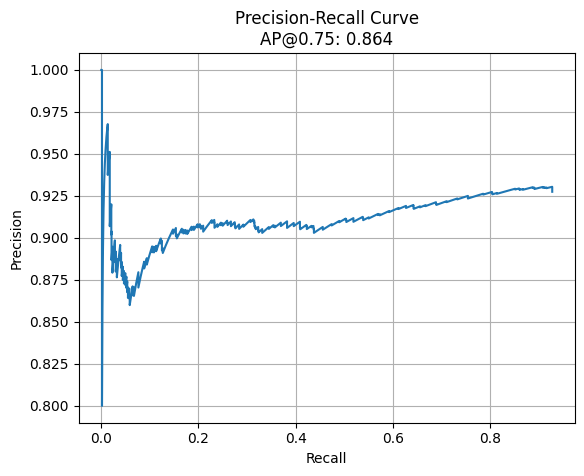

[0.929,
 0.873,
 0.777,
 0.863,
 0.948,
 0.919,
 0.866,
 np.float64(0.8949323914017304),
 np.float64(0.7859436889255855),
 np.float64(0.8635990978348888)]

In [ ]:
for imid, pth in enumerate(s05):
    AcDict=prediction_based_accuracy(pth)
    ious=AcDict.get('iou')
    mask_counts=AcDict.get('mask_count')
    ious_t=ious>=0.75
    ious_t=ious_t.astype(int)
    for i in np.arange(1,len(ious_t)):
        ious_t[i]+=ious_t[i-1]
    precision=ious_t/np.arange(1, len(ious_t)+1)
    recall=ious_t/(mask_counts)

    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    aps.append(ap)
    print(f"AP@0.75: {ap:.3f}")
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve'+'\n'+f"AP@0.75: {ap:.3f}")
    plt.grid()
    plt.savefig(f'figure/{imid}')
    plt.show()
aps

In [5]:
print('Color with Shadow Average AP@0.75: ', np.mean(aps))

Color with Shadow Average AP@0.75:  0.8719475178162204


In [ ]:
AcDict=prediction_based_accuracy('/DATA/vito/output/ran_synth_04_3000_bw/ran_synth_04_3000_bw_00_b250')
ious=AcDict.get('iou')
mask_counts=AcDict.get('mask_count')
ious_t=ious>=0.75
ious_t=ious_t.astype(int)
for i in np.arange(1,len(ious_t)):
    ious_t[i]+=ious_t[i-1]
precision=ious_t/np.arange(1, len(ious_t)+1)
recall=ious_t/(mask_counts)

mrec = np.concatenate(([0.0], recall, [1.0]))
mpre = np.concatenate(([0.0], precision, [0.0]))
for i in range(len(mpre) - 2, -1, -1):
    mpre[i] = max(mpre[i], mpre[i + 1])
idx = np.where(mrec[1:] != mrec[:-1])[0]
ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])


AP@0.75: 0.997


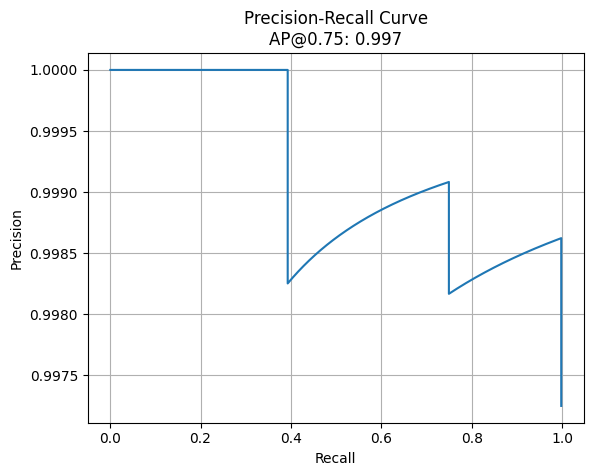

B&W [4,3000] AP@0.75: 0.997


In [3]:

print(f"AP@0.75: {ap:.3f}")
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve'+'\n'+f"AP@0.75: {ap:.3f}")
plt.grid()
plt.savefig(f'figure/bw04_3000')
plt.show()
print(f"B&W [4,3000] AP@0.75: {ap:.3f}")